# [Phystech@DataScience](https://thetahat.ru/courses/ph-ds-2025-spr)
## Домашнее задание 11

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_pds_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*

<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейках, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.

**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash;  60 баллов
* Задача 2 &mdash;  60 баллов

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):
* Задача 3 &mdash;  30 баллов
* Задача 4 &mdash;  30 баллов



-----

In [1]:
# Bot check

# HW_ID: phds_hw11
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn, optim
import matplotlib.pyplot as plt

from IPython.display import clear_output

from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set(palette="Set2")
from sklearn.metrics import mean_absolute_error

---
## <b><font color="blue">Легкая часть</font></b>
### Задача 1

#### *Профиль биология*

Мы будем исследовать датасет по экспрессиям различных генов (RNA-seq), используемых для предсказания возраста пациентов.

In [193]:
df = pd.read_csv("Rnaseq_age_reg.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Rnaseq_age_reg.csv'

Разбейте датасет на признаки и таргет, где в качестве таргета будет использоваться столбец `Age`, а признаки - все остальные. В том числе разбейте на подвыборки для обучения и теста.

**Переходите к общей части.**

#### *Профиль физика*

In [3]:
df = pd.read_csv("physics_data.csv", index_col=0)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,Eat
pubchem_id,,,,,,,,,,,,,,,,,,,,,
25004,-54.825075,-0.835719,45.240515,-22.585658,1.450320,-16.223986,12.376342,13.424011,-4.923189,-2.653680,...,-0.028997,-0.023466,-0.066633,0.030779,-0.036064,-0.008572,0.011805,-0.036215,0.052180,-19.013763
25005,-34.039832,24.930703,-7.485562,40.737762,21.400170,15.280596,4.467203,-19.296032,-0.433598,18.387221,...,-0.006840,-0.000419,0.003369,-0.000641,-0.001035,0.012597,0.004377,0.004023,0.003356,-10.161019
25006,-58.794258,-49.823448,-35.062080,1.698937,-18.012227,12.523468,9.210336,7.488163,11.392693,-0.927953,...,-0.004305,-0.003377,-0.003500,0.002734,-0.001017,0.004774,0.012796,0.022270,0.008051,-9.376619
25009,-38.508716,19.211767,-4.858507,10.484105,16.622411,-22.131178,-14.876963,-5.516521,13.793978,3.657935,...,0.028996,-0.001423,-0.000576,0.011144,-0.007253,-0.006700,-0.007940,0.022492,-0.007016,-13.776438
25011,-45.432604,-23.951574,-55.340413,-7.879883,-16.304009,13.340896,11.326496,6.784151,11.208725,-0.181278,...,0.004552,0.008307,-0.003005,0.000816,-0.000938,0.001135,-0.005256,0.001042,0.002651,-8.537140


Разбейте датасет на признаки и таргет, где в качестве таргета будет использоваться столбец Eat, а признаки - все остальные. В том числе разбейте на подвыборки для обучения и теста.

In [43]:
y = df['Eat']
X = df.drop(columns=['Eat'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_STATE)

### Общая часть

Отмасштабируйте данные:

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Обучите модель линейной регрессии и посмотрите на значения метрик на тесте. Что вы можете сказать про результат обучения?

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'Знчение MAPE: {mean_absolute_percentage_error(y_test, y_pred)}. Значение R2: {r2_score(y_test, y_pred)}')

Знчение MAPE: 0.34660042736702396. Значение R2: -18.7159603998162


Обучите линейные модели с регуляризациями, которые мы проходили ранее. Для каждой из моделей постройте графики зависимости метрик r2 и MAPE от коэфициента регуляризации. Можно пользоваться кодом из домашнего задания по регуляризации. Сильно ли улучшился результат? 

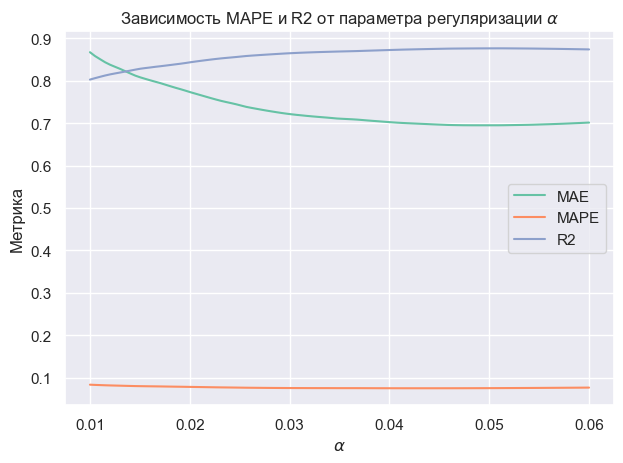

In [47]:
mapes = []
r2s = []
maes = []
alphas = np.linspace(0.01, 0.06, 100)
for alpha in alphas:
    model = ElasticNet(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mapes.append(mean_absolute_percentage_error(y_test, y_pred))
    r2s.append(r2_score(y_test, y_pred))    
    maes.append(mean_absolute_error(y_test, y_pred))
    
plt.plot(alphas, maes, label='MAE')  
plt.plot(alphas, mapes, label='MAPE')
plt.plot(alphas, r2s, label='R2')
plt.title(r'Зависимость MAPE и R2 от параметра регуляризации $\alpha$')
plt.xlabel(r'$\alpha$')
plt.ylabel('Метрика')
plt.tight_layout()
plt.legend()
plt.show()

In [39]:
argmax = np.argmax(r2s)
print(f'Максимальное значение метрики R2: {round(r2s[argmax], 2)}, наблюдается при \u03B1 = {round(alphas[argmax], 3)}')
argmin = np.argmax(-np.array(mapes))
print(f'Минимальное значение метрики MAPE: {round(mapes[argmin], 2)}, наблюдается при \u03B1 = {round(alphas[argmin], 3)}')

Максимальное значение метрики R2: 0.88, наблюдается при α = 0.051
Минимальное значение метрики MAPE: 0.07, наблюдается при α = 0.044


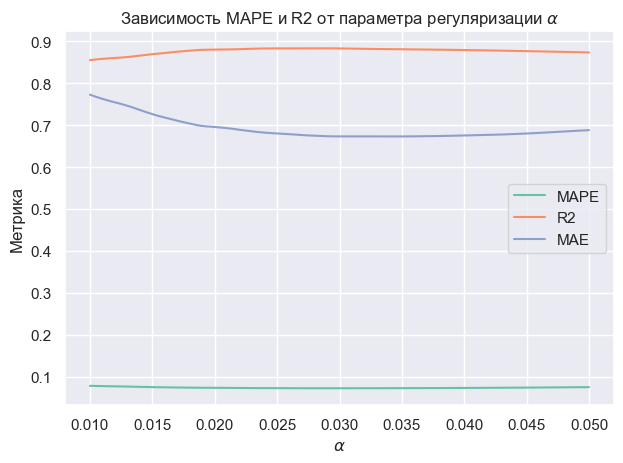

In [41]:
mapes = []
r2s = []
maes = []
alphas = np.linspace(0.01, 0.05, 100)
for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mapes.append(mean_absolute_percentage_error(y_test, y_pred))
    r2s.append(r2_score(y_test, y_pred))
    maes.append(mean_absolute_error(y_test, y_pred))
    
plt.plot(alphas, maes, label='MAE')
plt.plot(alphas, mapes, label='MAPE')
plt.plot(alphas, r2s, label='R2')
plt.title(r'Зависимость MAPE и R2 от параметра регуляризации $\alpha$')
plt.xlabel(r'$\alpha$')
plt.ylabel('Метрика')
plt.tight_layout()
plt.legend()
plt.show()

In [264]:
argmax = np.argmax(r2s)
print(f'Максимальное значение метрики R2: {round(r2s[argmax], 2)}, наблюдается при \u03B1 = {round(alphas[argmax], 3)}')
argmin = np.argmax(-np.array(mapes))
print(f'Минимальное значение метрики MAPE: {round(mapes[argmin], 2)}, наблюдается при \u03B1 = {round(alphas[argmin], 3)}')

Максимальное значение метрики R2: 0.88, наблюдается при α = 0.029
Минимальное значение метрики MAPE: 0.07, наблюдается при α = 0.029


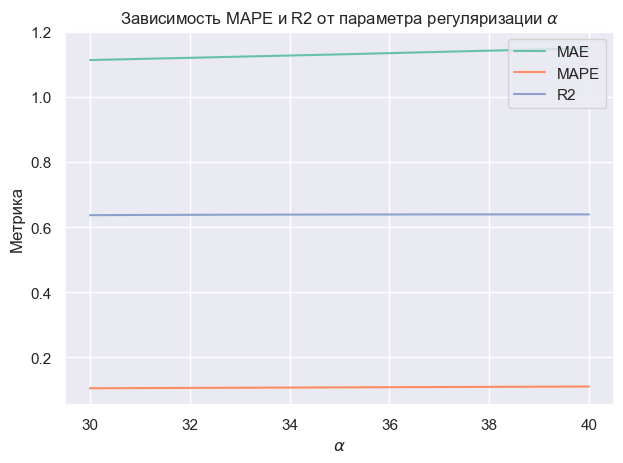

In [48]:
mapes = []
r2s = []
maes = []
alphas = np.linspace(30, 40, 100)
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mapes.append(mean_absolute_percentage_error(y_test, y_pred))
    r2s.append(r2_score(y_test, y_pred))
    maes.append(mean_absolute_error(y_test, y_pred))
    
plt.plot(alphas, maes, label='MAE')
plt.plot(alphas, mapes, label='MAPE')
plt.plot(alphas, r2s, label='R2')
plt.title(r'Зависимость MAPE и R2 от параметра регуляризации $\alpha$')
plt.xlabel(r'$\alpha$')
plt.ylabel('Метрика')
plt.tight_layout()
plt.legend()
plt.show()

In [49]:
argmax = np.argmax(r2s)
print(f'Максимальное значение метрики R2: {round(r2s[argmax], 2)}, наблюдается при \u03B1 = {round(alphas[argmax], 2)}')
argmin = np.argmax(-np.array(mapes))
print(f'Минимальное значение метрики MAPE: {round(mapes[argmin], 2)}, наблюдается при \u03B1 = {round(alphas[argmin], 2)}')

Максимальное значение метрики R2: 0.64, наблюдается при α = 38.69
Минимальное значение метрики MAPE: 0.11, наблюдается при α = 30.0


Выберите оптимальный, на вашь взгляд, параметр для L1-регуляризации, обучите модель Lasso-регрессии, выведите ещё раз метрики r2 и MAPE и проведите отбор признаков: уберите из датасета все те, для которых коэффициент регрессии оказался нулевым.

In [50]:
alpha = 0.029
model = Lasso(alpha=alpha)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'Знчение MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2f}. Значение R2: {r2_score(y_test, y_pred):.2f}')

Знчение MAPE: 0.07. Значение R2: 0.88


In [51]:
coefs = model.coef_
indexes = []
for i in range(len(coefs)):
    if coefs[i] == 0:
        indexes.append(i)
X_train_dropped = np.delete(X_train, indexes, axis=1)
X_test_dropped = np.delete(X_test, indexes, axis=1)

Теперь обучите простейшую нейронную сеть на уменьшенном датасете, сравните результат с результатами обучения других моделей.

**Подсказка** Используйте nn.Sequential()

In [59]:
in_features = X_train_dropped.shape[1]
X_train_new = torch.FloatTensor(X_train_dropped)
y_train_new = torch.FloatTensor(y_train.values.reshape(-1, 1))
X_test_new = torch.FloatTensor(X_test_dropped)

In [60]:
model = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=in_features),
    nn.Sigmoid(),
    nn.Linear(in_features=in_features, out_features=in_features),
    nn.ReLU(),
    nn.Linear(in_features=in_features, out_features=1),
)

In [61]:
optim_func = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [62]:
num_iter = 100000

for i in range(num_iter):
    y_pred = model(X_train_new)
    loss = optim_func(y_pred, y_train_new)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (i + 1) % 10000 == 0:
        print(f'Epoch [{i+1}/{num_iter}], Loss: {loss.item():.4f}')

Epoch [10000/100000], Loss: 2.5208
Epoch [20000/100000], Loss: 2.1405
Epoch [30000/100000], Loss: 1.7480
Epoch [40000/100000], Loss: 1.3205
Epoch [50000/100000], Loss: 0.8995
Epoch [60000/100000], Loss: 0.5885
Epoch [70000/100000], Loss: 0.4131
Epoch [80000/100000], Loss: 0.3395
Epoch [90000/100000], Loss: 0.3067
Epoch [100000/100000], Loss: 0.2900


In [63]:
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X_test_new)).numpy()

print(f'R2: {round(r2_score(y_test, y_pred), 2)} \nMAPE: {round(mean_absolute_percentage_error(y_test, y_pred), 2)}')

R2: 0.89 
MAPE: 0.07


In [64]:
print(f'MAE: {round(mean_absolute_error(y_test, y_pred), 2)}')

MAE: 0.65


**Вопрос:** объясните полученный результат.

Простейшая нейронная сеть уже нелинейная, поэтому R2 метрика плохая (низкая). Однако MAPE и MAE тоже не сильно хорошая (низкая). Наверно, архитектура нейронной сети подобрана непраивльно. Хотя я пробовал вставлять сигмоиды, РеЛу. Странно, но если модель лучше оптимизирует функцию Лосса, которая в данном случаев эквивалентна метрике MAE, то на тестовой выборке результат был хуже. Возможно, это особенность данных и нужно продолжать экспериментировать

Сравните все модели, поясняя полученные результаты и значения метрик.

**Вывод:** Лучше всего с оптимизацией MAE метрики справились Ridge регуляризация и нейронная сеть. Но нейронная сеть более гибкая, с ней удобнее работать, можно очень хорошо оптимизировать нужную метрику, поэтому она лучше

---
### Задача 2
#### *Профиль физика*

Скачайте [датасет](https://www.kaggle.com/datasets/omidbaghchehsaraei/identification-of-two-modes-of-z-boson?resource=download), описывающий распады Z-бозонов двух типов: `Zee`и `Zmumu`. Создайте и обучите нейросеть, разделяющую эти два класса.


In [78]:
data = pd.read_csv('Z_boson.csv')
data.head(3)

,Unnamed: 0,Run,Event,pt1,eta1,phi1,Q1,pt2,eta2,phi2,Q2,class
0,0,166784,20257329,42.9130,-1.3248,-3.0057,-1,42.2897,-0.6624,0.3485,1,Zmumu
1,1,163261,64679856,39.8744,-0.0057,-0.7744,-1,36.3997,1.3710,2.2952,1,Zee
2,2,165570,196860468,72.9296,-0.4162,0.9198,1,39.5410,-0.2680,-1.4629,1,Zee


Удалите столбцы `Unnamed: 0`, `Run` и `Event`, так как это не физические величины. Удалите строки, где есть пропуски, если таковые имеются.

In [79]:
data.drop(columns=['Unnamed: 0', 'Run', 'Event'], inplace=True)
data.dropna(inplace=True)

In [80]:
data.head(3)

,pt1,eta1,phi1,Q1,pt2,eta2,phi2,Q2,class
0,42.9130,-1.3248,-3.0057,-1,42.2897,-0.6624,0.3485,1,Zmumu
1,39.8744,-0.0057,-0.7744,-1,36.3997,1.3710,2.2952,1,Zee
2,72.9296,-0.4162,0.9198,1,39.5410,-0.2680,-1.4629,1,Zee


Также можно как-нибудь взглянуть на признаки. Возможно, не все они вносят вклад в разделение классов. Не забудьте преобразовать таргет (столбец `class`) к формату 0 и 1. Вам может пригодиться `sklearn.preprocessing.LabelBinarizer`.


<Figure size 2000x1000 with 0 Axes>

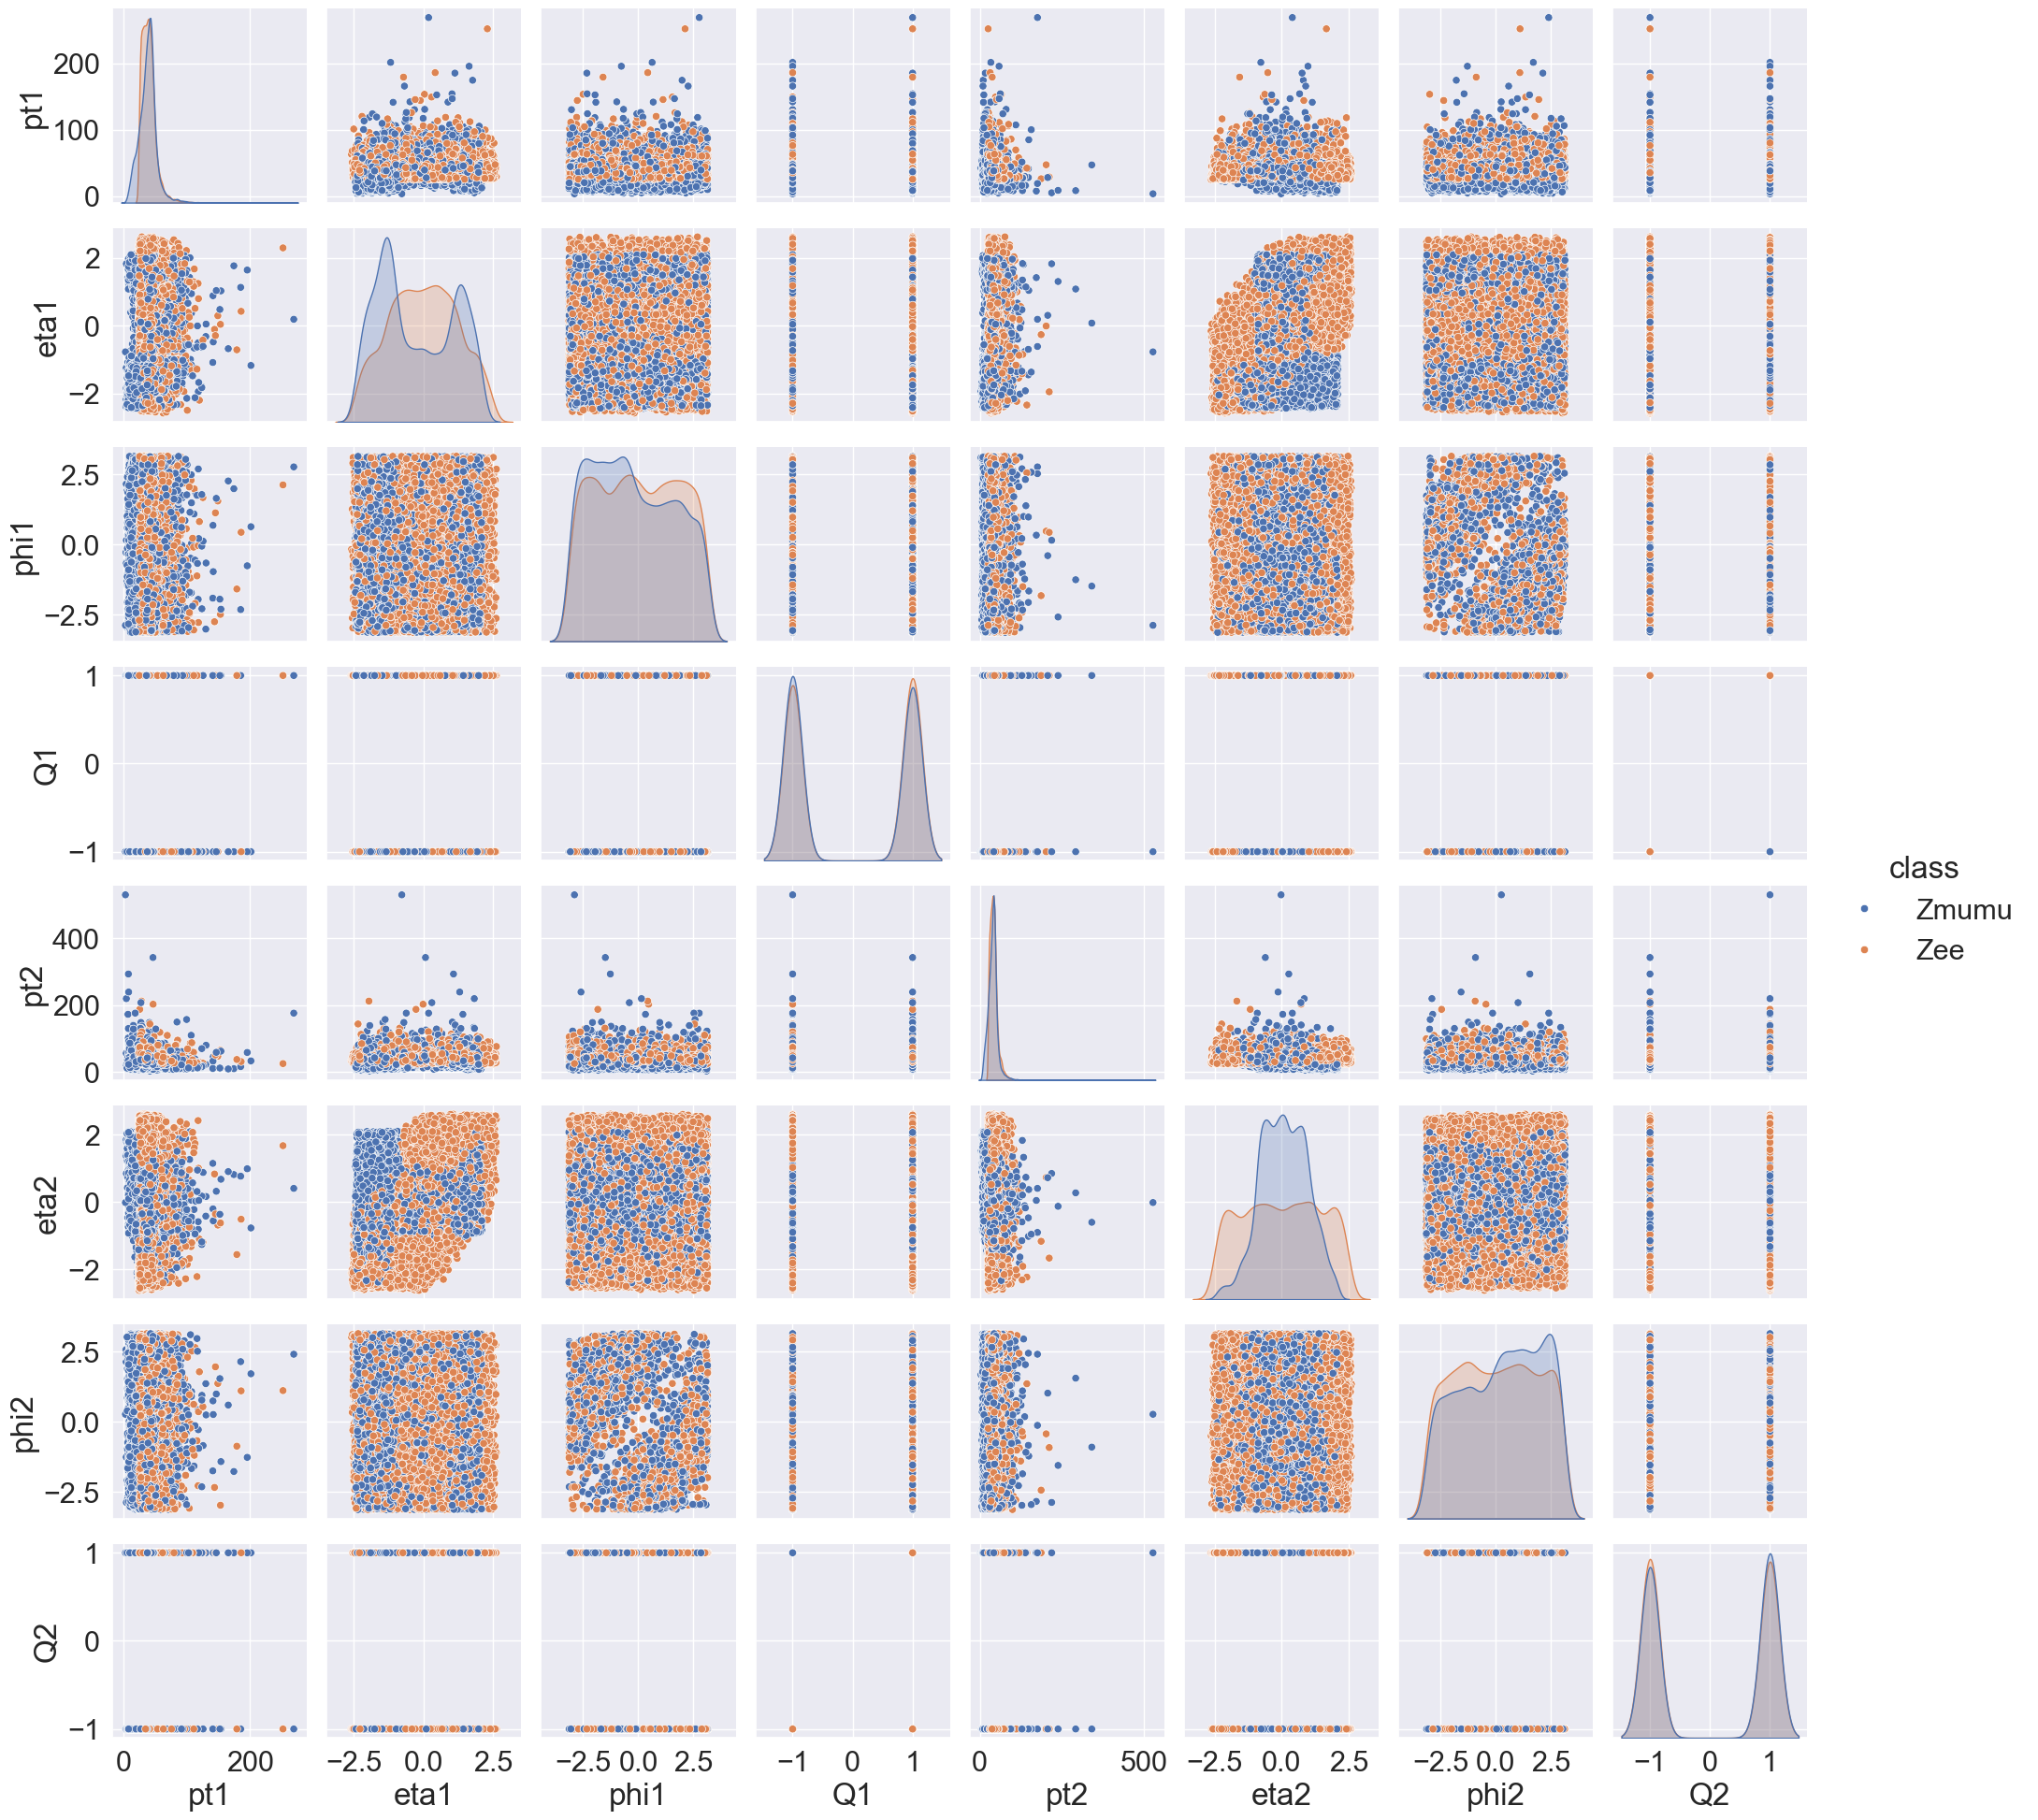

In [81]:
plt.figure(figsize=(20, 10))
sns.set_theme(font_scale=2.0)
sns.pairplot(data, hue="class", palette="deep")

In [82]:
from sklearn.preprocessing import LabelBinarizer

Какие признаки вы бы использовали для разделения людей по классам? Выберите эти столбцы и создайте наборы train и test с помощью функции train_test_split, а также выделите набор данных для валидации при обучении.

In [101]:
# исходя из графиков, отберём признаки для обучения
selected_features = ['Q2', 'Q1', 'eta2', 'eta1']
X = data[selected_features]

In [102]:
# таргет преобразуем из строк "Zee", "Zmumu" к 0 и 1
y = data['class']
y = LabelBinarizer().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)
X_val, X_test, y_val, y_test  = train_test_split(X_test, y_test, train_size=0.3)

**Переходите к общей части.**

### Профиль биология

Скачайте [датасет](https://www.kaggle.com/datasets/sooyoungher/smoking-drinking-dataset), описывающий влияние курения и алкоголя на человека. Создайте и обучите нейросеть, разделяющую эти два класса.

In [103]:
df = pd.read_csv("smoking_driking_dataset_Ver01.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'smoking_driking_dataset_Ver01.csv'

In [ ]:
df.describe()

In [ ]:
df.columns, df.shape

In [154]:
column_names = df.columns[1:-2]# нам не нужны гендер и таргеты сейчас

In [ ]:
column_names

Попробуем классифицировать людей с плохими привычками и без них, чтобы облегчить нам задачу. Для этого создадим дополнительный столбец в таблице, который будет содержать информацию о том, имеет ли человек вредные привычки или нет.

In [156]:
def smoking_preprocessing(x):
  if x == 3 or x == 2:
    return 1
  else:
    return 0

def drinking_preprocessing(x):
  if x == 'Y':
    return 1
  else:
    return 0

In [157]:
df['SMK_stat_type_cd'] = df['SMK_stat_type_cd'].apply(func = smoking_preprocessing)
df['DRK_YN'] = df['DRK_YN'].apply(func = drinking_preprocessing)

In [158]:
df['bad_habits'] = df['DRK_YN']+df['SMK_stat_type_cd']-df['DRK_YN']*df['SMK_stat_type_cd']

Теперь смотрим на разделение по привычкам

In [ ]:
graph = sns.PairGrid(df.iloc[:1000], hue='bad_habits', vars = column_names[:7])
graph.map_upper(sns.scatterplot)
graph.map_lower(sns.kdeplot)
graph.map_diag(sns.kdeplot)
graph.add_legend()

In [ ]:
graph = sns.PairGrid(df.iloc[:1000], hue='bad_habits', vars = column_names[7:15])
graph.map_upper(sns.scatterplot)
graph.map_lower(sns.kdeplot)
graph.map_diag(sns.kdeplot)
graph.add_legend()

In [ ]:
graph = sns.PairGrid(df.iloc[:1000], hue='bad_habits', vars = column_names[15:])
graph.map_upper(sns.scatterplot)
graph.map_lower(sns.kdeplot)
graph.map_diag(sns.kdeplot)
graph.add_legend()

In [159]:
target_1 = df.pop('SMK_stat_type_cd')
target_2 = df.pop('DRK_YN')
target_3 = df.pop('bad_habits')

Какие признаки вы бы использовали для разделения людей по классам? Выберите эти столбцы и создайте наборы train и test с помощью функции train_test_split, а также выделите набор данных для валидации при обучении.

In [160]:
# исходя из графиков, отберём признаки для обучения (нас интересуют вредные привычки)
selected_features = [<...>]
X = data[selected_features]

In [161]:
# данных очень много, поэтому для экономии времени автор ноутбука отводит на обучение всего треть датасета
X_train, X_test, y_train, y_test = train_test_split(X, target_3, train_size=0.3)
X_val, X_test, y_val, y_test  = train_test_split(X_test, y_test, train_size=0.3)

## Общая часть

Как вы помните, в задаче классификации предсказывается вероятность. На основании этой вероятности можно делать вывод о принадлежности объекта к тому или иному классу. Причём не всегда используется порог $P=0.5$. Например, если классы несбалансированы, это значение можно варьировать на интервале (0, 1). Предоставляем вам возможность самим выбрать этот порог и поэкспериментировать.

In [161]:
class_lim_proba = 0.5 # критерий принадлежности к тому или иному классу

Стандартизируйте данные

In [162]:
X_train_scaled = StandardScaler().fit_transform(X_train)
X_val_scaled = StandardScaler().fit_transform(X_val)
X_test_scaled = StandardScaler().fit_transform(X_test)

Напишем функцию для отрисовки кривых обучения. На одном графике расположим значение функции потерь на трейне и валидации, а на другом &mdash; значение метрики качества на ваш выбор, также для трейна и валидации.

In [163]:
def plot_learning_curves(history):
    '''
    Функция для отображения лосса и метрики во время обучения.
    '''
    clear_output(wait=True)

    fig = plt.figure(figsize=(20, 7))
    fontsize = 15   # размер шрифта

    plt.subplot(1,2,1)
    plt.title('Лосс', fontsize=fontsize)
    plt.plot(history['loss_train'], label='train')
    plt.plot(history['loss_val'],   label='val')
    plt.ylabel('лосс',  fontsize=fontsize)
    plt.xlabel('эпоха', fontsize=fontsize)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title('Метрика', fontsize=fontsize)
    plt.plot(history['metric_train'], label='train')
    plt.plot(history['metric_val'],   label='val')
    plt.ylabel('Значение метрики', fontsize=fontsize)
    plt.xlabel('эпоха',    fontsize=fontsize)
    plt.legend()
    plt.show()

Напишите функцию метрики, которую вы будете использовать, например accuracy.

In [107]:
from sklearn.metrics import accuracy_score

In [109]:
def metric(y_true, y_pred):
    metric = np.sum((y_pred_train.detach().numpy() >= class_lim_proba) == local_y_train.numpy()) / len(local_y_train)
    return metric

#### Создание модели.
В семинаре вы у промежуточных слоёв задавали `in_features = out_features = 1`, а в данном случае вам надо будет создать нейросеть из нескольких слоёв, поставив только у последнего из них `out_features = 1`.

Какой должна быть размерность входа первого слоя?

In [178]:
in_features = 4
model = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=1),
    nn.Sigmoid(),
)
model


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=128, bias=True)
  (7): ReLU()
  (8): Linear(in_features=128, out_features=64, bias=True)
  (9): ReLU()
  (10): Linear(in_features=64, out_features=1, bias=True)
  (11): Sigmoid()
)

#### Обучение

В качетсве функции потерь возьмите [бинарную кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), а шаг градиентного спуска установите равным 0.5. Можете взять и другие loss и `lr`, если хотите поэкспериментировать.

In [179]:
optim_func = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

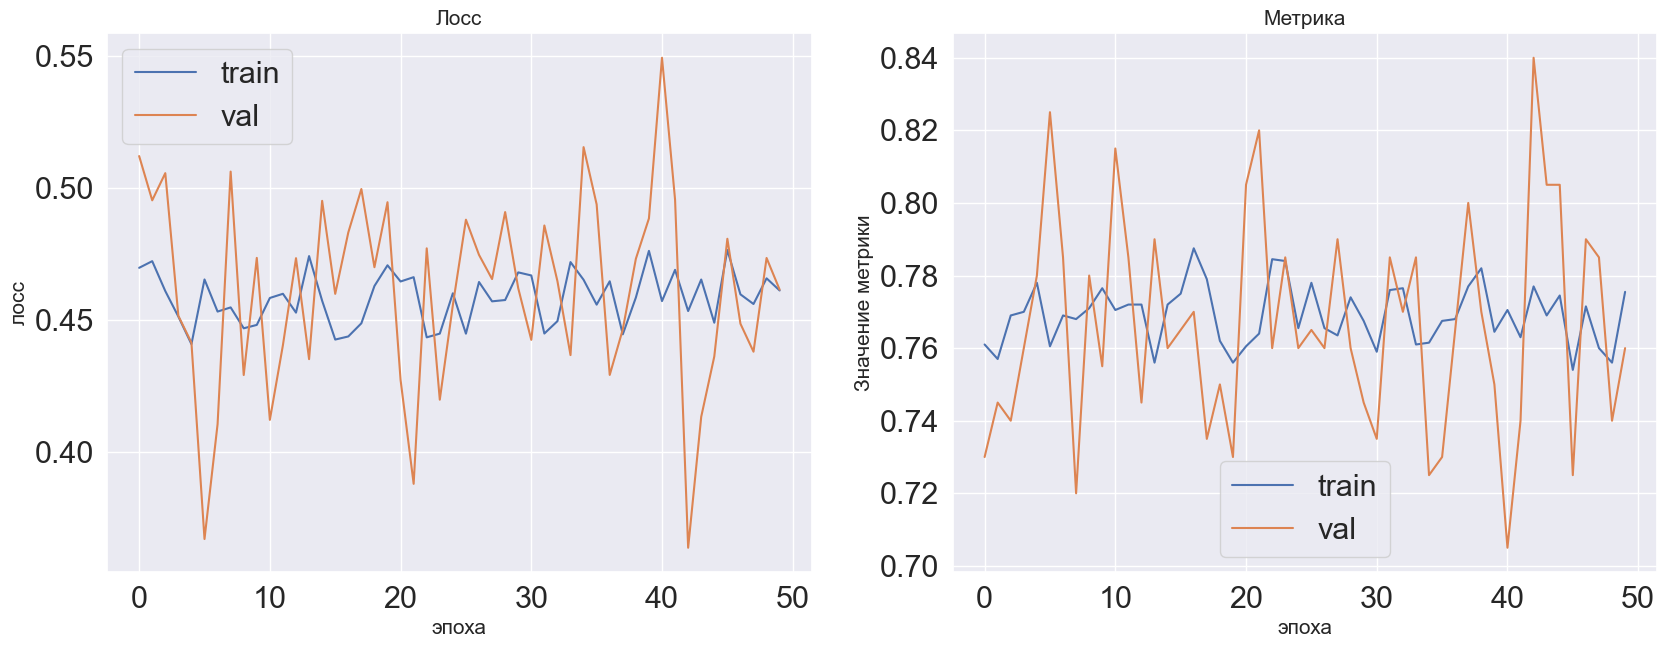

In [181]:
batch_size = 2000 # этот
num_iter = 50    # и этот параметры можете также поварьировать
history = {
    'loss_train': [],
    'loss_val': [],
    'metric_train': [],
    'metric_val': [],
}

for i in range(num_iter):
    
    # Так как размер выборки слишком велик, то будем обучать лишь на части данных
    indexes_train = np.random.choice(np.arange(len(X_train)), batch_size, replace=False)
    local_X_train = torch.FloatTensor(X_train_scaled[indexes_train])
    local_y_train = torch.FloatTensor(y_train[indexes_train])

    indexes_val = np.random.choice(np.arange(len(X_val)), batch_size//10, replace=False)
    local_X_val = torch.FloatTensor(X_val_scaled[indexes_val])
    local_y_val = torch.FloatTensor(y_val[indexes_val])
 
    # Forward pass: предсказание модели по данным X_train
    y_pred_train = model(local_X_train)
    with torch.no_grad():
        y_pred_val = model(local_X_val)

    # Вычисление оптимизируемой функции (MSE) по предсказаниям
    loss_train = optim_func(y_pred_train, local_y_train)
    with torch.no_grad():
        loss_val = optim_func(y_pred_val, local_y_val)

    # Backward pass: вычисление градиентов оптимизируемой функции
    # по всем параметрам модели
    loss_train.backward()

    # Оптимизация: обновление параметров по формулам соответствующего
    # метода оптимизации, используются вычисленные ранее градиенты
    optimizer.step()

    # Зануление градиентов
    optimizer.zero_grad()

    # Считаем метрику на эпохе (здесь посчитана accuracy, можете реализовать любую другую за доп. баллы)
    metric_train = np.sum((y_pred_train.detach().numpy() >= class_lim_proba) == local_y_train.numpy()) / len(local_y_train)
    metric_val = np.sum((y_pred_val.detach().numpy() >= class_lim_proba) == local_y_val.numpy()) / len(local_y_val)

    # Сохраняем результаты эпохи
    history['loss_train'].append(loss_train.item())
    history['loss_val'].append(loss_val.item())
    history['metric_train'].append(metric_train)
    history['metric_val'].append(metric_val)

    # График Метрики + Лосса для трейна и валидации каждую итерацию
    plot_learning_curves(history)

Тестирование

In [182]:
with torch.no_grad():
      y_pred_test = model(torch.FloatTensor(X_test_scaled))
      loss_test = optim_func(y_pred_test, torch.FloatTensor(y_test))
      metric_test = np.sum((y_pred_test.detach().numpy() >= class_lim_proba) == y_test) / len(y_test)
print(f" Test Loss: {loss_test} \n Test metric: {metric_test}")

 Test Loss: 0.464701384305954 
 Test metric: 0.7707142857142857


**Выводы:** Перед обучением модели стоит посмотреть распределения признаков и выбрать только самые лучшие для текущей задачи. Нейронные сети могут достаточно хорошо обучиться (метрика accuracy 77%), но ниже этого значения у меня так и не вышло сделать, применяя разные слои, глубину слоя, количество слоёв, перебор гиперпараметров. Кажется, что используемые в моей архитектуре функции задают свой фиксированный минимум, который находится градиентным спуском, а чтобы изменить минимум, нужно применять другие архитектуры.

---
## <b><font color="orange">Сложная часть</font></b>
### Задача 3

В этой задаче мы будем вручную реализовывать усложнение для линейной регрессии, которое вы рассматривали на семинаре. 

Запрещено использовать torch.nn (саму библиотеку torch использовать можно и нужно). Чтобы иметь перед глазами оставим здесь формулы:

$$\widehat{y}(x) = w_1u(x) + b_1,$$

$$u(x) = \sigma(w_0x + b_0),$$

$$\sigma(x) = \text{ReLU}(x) = \begin{equation*}\begin{cases}x, \; x \ge 0, \\ 0, \; \text{иначе,} \end{cases} \end{equation*}$$

$w_0, b_0 \in \mathbb{R}$ &mdash; обучаемые параметры первого слоя, $w_1, b_1 \in \mathbb{R}$ &mdash; обучаемые параметры второго слоя, $\sigma(x)$ &mdash; функция активации, в данном случае мы выбрали `ReLU`.

Реализуйте функцию активации:

In [219]:
def act_func(x):
    return x * (x >= 0)

Задайте оптимизируемую функцию / функцию ошибки / лосс — [MSE](https://miptstats.github.io/courses/ad_fivt/linreg_sklearn.html#3.-Тестирование-и-оценка-качества):

$$
    MSE(\widehat{y}, y) = \frac{1}{n}\sum_{i=1}^n\left(\widehat y_i - y_i\right)^2
$$

In [220]:
def optim_func(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

Обучите вашу модель на данных профиля, которые вы выбрали в 1-й задаче. Выберите **1** признак, на котором проводите обучение.

In [221]:
df = pd.read_csv("physics_data.csv", index_col=0)
df.head(3)

,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,Eat
pubchem_id,,,,,,,,,,,,,,,,,,,,,
25004,-54.825075,-0.835719,45.240515,-22.585658,1.450320,-16.223986,12.376342,13.424011,-4.923189,-2.653680,...,-0.028997,-0.023466,-0.066633,0.030779,-0.036064,-0.008572,0.011805,-0.036215,0.052180,-19.013763
25005,-34.039832,24.930703,-7.485562,40.737762,21.400170,15.280596,4.467203,-19.296032,-0.433598,18.387221,...,-0.006840,-0.000419,0.003369,-0.000641,-0.001035,0.012597,0.004377,0.004023,0.003356,-10.161019
25006,-58.794258,-49.823448,-35.062080,1.698937,-18.012227,12.523468,9.210336,7.488163,11.392693,-0.927953,...,-0.004305,-0.003377,-0.003500,0.002734,-0.001017,0.004774,0.012796,0.022270,0.008051,-9.376619


In [227]:
x = torch.FloatTensor(df['0'].values)
y = torch.FloatTensor(df['Eat'].values)

In [228]:
# Инициализация параметров
w0 = torch.ones(1, requires_grad=True)
b0 = torch.ones(1, requires_grad=True)
w1 = torch.ones(1, requires_grad=True)
b1 = torch.ones(1, requires_grad=True)


# Количество итераций
num_iter = 1000

# Скорость обучения для параметров
lr_w = 0.01
lr_b = 0.05

for i in range(num_iter):

    # Forward pass: предсказание модели
    y_pred = act_func(x * w0 + b0) * w1 + b1

    # Вычисление оптимизируемой функции (MSE)
    loss = optim_func(y_pred, y)
    # Bakcward pass: вычисление градиентов
    loss.backward()

    # Оптимизация: обновление параметров
    w0.data -= lr_w * w0.grad.data
    b0.data -= lr_b * b0.grad.data
    w1.data -= lr_w * w1.grad.data
    b1.data -= lr_b * b1.grad.data

    # Зануление градиентов
    w0.grad.zero_()
    b0.grad.zero_()
    w1.grad.zero_()
    b1.grad.zero_()

**Вывод:** Обучение модели состоит из шагов: ининциализация обучающей выборки, инициализация параметров, задание гиперпараметров, проход вперёд, вычисление лосса, прохлж назад, оптимизация параметров, зануление градиентов

---
### Задача 4

Рассмотрим двуслойную нейронную сеть, которая принимает на вход $x\in\mathbb{R}$ и возвращает $y\in\mathbb{R}$. Выход первого слоя возвращает $u \in\mathbb{R}^2$. После первого слоя используется функция активации $\sigma(x) = \frac{1}{1 + \exp(-x)}$, после второго слоя функция активации не используется (или используется тождественная). Тем самым нашу нейронку можно представить в виде

$$\widehat{y}(x) = \sum_{h=1}^2 w_{2h}u_h(x) + b_2,$$

$$u_h(x) = \sigma(w_{1h}x + b_{1h}),$$

$$\text{где} \; h \in \{1, 2\}.$$





**1.** Нарисуйте схематически данную нейронную сеть. Сколько у нее обучаемых параметров?

...

**2.** Пусть нам дана обучающая выборка $(X_1, Y_1), ..., (X_n, Y_n)$, где $X_i \in \mathbb{R}$ и $Y_i \in \mathbb{R}$. Нейронная сеть обучается по этой выборке, минимизируя заданную функцию $L$ &mdash; функцию ошибки. Положим, что $L$ &mdash; это MSE:
$$\text{MSE} = L(X, Y) = \frac{1}{n}\sum_{i=1}^n \big(Y_i - \widehat{y}(X_i)\big)^2.$$

Наша задача &mdash; найти оптимальные параметры нашей модели для минимизации $L(X, Y)$ на заданном наборе данных. Мы будем решать эту задачу с помощью градиентного спуска. Для этого нам понадобится выписать производные по всем параметрам сети. Конечно, в данном случае довольно просто выписать все производные напрямую. Однако мы воспользуемся следующей хитростью: мы будем считать производные поэтапно, причем начнем с конца вычислительной цепочки и, используя формулу производной сложной функции, последовательно посчитаем все необходимые производные. Этот процесс называется методом **обратного распространения ошибки (backpropagation)**.


**2.1.** Начнем с производной MSE по выходам сети:
$$\frac{\partial\:\text{MSE}}{\partial \widehat{y}(X_i)} = \; ...$$

**2.2** Возьмем производные выходов сети по параметрам последнего слоя

$$\frac{\partial \widehat{y}(X_i)}{\partial w_{2h}} = \; ...$$

$$\frac{\partial \widehat{y}(X_i)}{\partial b_2} = \; ...$$

Также выпишем производные выходов сети по входам последнего слоя:

$$\frac{\partial \widehat{y}(X_i)}{\partial u_h(X_i)} = \; ...$$

Теперь выпишем производные MSE по параметрам и входам последнего слоя. Для этого вспомните правило производной сложной функции из математического анализа. Обратите внимание на то, что нам не нужно прописывать все производные до конца, достаточно заполнить пропуски в записи ниже:

$$\frac{\partial\:\text{MSE}}{\partial w_{2h}} = \sum_{i=1}^n \frac{\partial\:\text{MSE}}{\partial ...} \frac{\partial ...}{\partial w_{2h}}$$

$$\frac{\partial\:\text{MSE}}{\partial b_2} = \sum_{i=1}^n \frac{\partial\:\text{MSE}}{\partial ...} \frac{\partial ...}{\partial b_2}$$

$$\frac{\partial\:\text{MSE}}{\partial u_h} = \sum_{i=1}^n \frac{\partial\:\text{MSE}}{\partial ...} \frac{\partial ...}{\partial u_h}$$

**2.3.** Теперь будем разбираться с производными по параметрам первого слоя.

Для начала нам пригодится производная функции активации, запишите ее так, чтобы ответе осталась функция от $\sigma(x)$:

$$\frac{\partial\:\sigma(x)}{\partial x} = \; ...$$

Теперь возьмем производные выходов первого слоя по его параметрам:

$$\frac{\partial u_h(X_i)}{\partial w_{1h}} = \; ...$$

$$\frac{\partial u_h(X_i)}{\partial b_{1h}} = \; ...$$

Наконец, выпишем производные MSE по параметрам первого слоя. Так же как и раньше достаточно заполнить пропуски в записи ниже:

$$\frac{\partial\:\text{MSE}}{\partial w_{1h}} = \; \sum_{i=1}^n \frac{\partial\:\text{MSE}}{\partial ...} \frac{\partial ...}{\partial w_{1h}}$$

$$\frac{\partial\:\text{MSE}}{\partial b_{1h}} = \; \sum_{i=1}^n \frac{\partial\:\text{MSE}}{\partial ...} \frac{\partial ...}{\partial b_{1h}}$$

**3.** Пусть обучающая выборка очень большая. Что нужно делать в таком случае? Запишите, как нужно поменять правило обновления параметров.

...

**Вывод:**

...